# LAB 7 —  Object Detection

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:**

## Learning objectives
**Context:** you will fine-tune a small YOLO detector on a small blood-cell dataset and analyze the results.


## Dataset
We will use the **BCCD Blood Cell Detection Dataset**, which contains microscope images with bounding-box annotations for:

- `RBC` — red blood cells
- `WBC` — white blood cells
- `Platelets`



>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


# 0. Installation


In [1]:
!pip install -q ultralytics opencv-python matplotlib pyyaml lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.7 MB/s eta 0:00:00


# 1. Imports and hardware configuration

This cell automatically selects GPU if available.  
If you want to force CPU mode, set `FORCE_CPU = True`.

In [2]:
from pathlib import Path
import os
import random
import shutil
import zipfile
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FORCE_CPU = False

if torch.cuda.is_available() and not FORCE_CPU:
    DEVICE = 0
    HARDWARE = "GPU"
else:
    DEVICE = "cpu"
    HARDWARE = "CPU"

print("Hardware mode:", HARDWARE)
print("Training device:", DEVICE)

if HARDWARE == "GPU":
    IMG_SIZE = 416
    EPOCHS = 15
    BATCH = 8
    MAX_IMAGES = 160
else:
    IMG_SIZE = 320
    EPOCHS = 3
    BATCH = 2
    MAX_IMAGES = 80

print(f"IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH={BATCH}, MAX_IMAGES={MAX_IMAGES}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hardware mode: GPU
Training device: 0
IMG_SIZE=416, EPOCHS=15, BATCH=8, MAX_IMAGES=160


# 2. Download the dataset

We download BCCD from GitHub.  
The original annotations are in **Pascal VOC XML format**, so we will convert them to **YOLO format** later.

Expected original structure:

```text
BCCD/
├── Annotations/
├── JPEGImages/
└── ImageSets/
```

In [3]:
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
WORKDIR = ROOT / "object_detection_tp"
RAW_DIR = WORKDIR / "raw_bccd"
YOLO_DIR = WORKDIR / "bccd_yolo"

WORKDIR.mkdir(parents=True, exist_ok=True)

url = "https://github.com/Shenggan/BCCD_Dataset/archive/refs/heads/master.zip"
zip_path = WORKDIR / "bccd_master.zip"

if not zip_path.exists():
    print("Downloading BCCD dataset...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("Zip file already exists.")

if not RAW_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(WORKDIR)
    extracted = WORKDIR / "BCCD_Dataset-master" / "BCCD"
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for item in extracted.iterdir():
        shutil.copytree(item, RAW_DIR / item.name, dirs_exist_ok=True)
else:
    print("Raw dataset already exists.")

print("RAW_DIR:", RAW_DIR)
print("Number of images:", len(list((RAW_DIR / "JPEGImages").glob("*.jpg"))))
print("Number of annotations:", len(list((RAW_DIR / "Annotations").glob("*.xml"))))

Extracting dataset...
RAW_DIR: /content/object_detection_tp/raw_bccd
Number of images: 364
Number of annotations: 364


# 3. Understand annotation formats

## 3.1 Pascal VOC format

The original dataset uses XML files. A bounding box is stored as:

```text
xmin, ymin, xmax, ymax
```

These are pixel coordinates.

## 3.2 YOLO format

YOLO expects one `.txt` file per image. Each row has:

```text
class_id x_center y_center width height
```

Important: YOLO coordinates are **normalized** between 0 and 1.

Example:

```text
1 0.52 0.43 0.20 0.30
```

This means:

- class ID = 1
- center x = 52% of image width
- center y = 43% of image height
- box width = 20% of image width
- box height = 30% of image height

# 4. Convert BCCD annotations to YOLO format

The following cells create the YOLO-compatible dataset structure:

```text
bccd_yolo/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```


In [4]:
CLASS_NAMES = ["RBC", "WBC", "Platelets"]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def voc_box_to_yolo(box, img_w, img_h):
    """
    Convert a Pascal VOC box [xmin, ymin, xmax, ymax] in pixels
    to YOLO normalized format [x_center, y_center, width, height].
    """
    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height

def parse_voc_xml(xml_path):
    """Parse one Pascal VOC XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_TO_ID:
            continue

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "class_id": CLASS_TO_ID[class_name],
            "box_xyxy": [xmin, ymin, xmax, ymax],
            "box_yolo": voc_box_to_yolo([xmin, ymin, xmax, ymax], img_w, img_h)
        })

    return img_w, img_h, objects

In [5]:
def prepare_yolo_dataset(max_images=160, train_ratio=0.70, val_ratio=0.20):
    # Remove previous converted dataset to keep the notebook reproducible 😉
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)

    for split in ["train", "val", "test"]:
        (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    image_paths = sorted((RAW_DIR / "JPEGImages").glob("*.jpg"))
    image_paths = image_paths[:max_images]
    random.shuffle(image_paths)

    n = len(image_paths)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)

    splits = {
        "train": image_paths[:n_train],
        "val": image_paths[n_train:n_train + n_val],
        "test": image_paths[n_train + n_val:]
    }

    split_counts = {}
    class_counter = Counter()

    for split, paths in splits.items():
        split_counts[split] = len(paths)

        for img_path in paths:
            xml_path = RAW_DIR / "Annotations" / f"{img_path.stem}.xml"
            img_w, img_h, objects = parse_voc_xml(xml_path)

            # Copy image
            dst_img = YOLO_DIR / "images" / split / img_path.name
            shutil.copy2(img_path, dst_img)

            # Write YOLO label
            label_path = YOLO_DIR / "labels" / split / f"{img_path.stem}.txt"
            with open(label_path, "w") as f:
                for obj in objects:
                    class_counter[obj["class_name"]] += 1
                    x_center, y_center, width, height = obj["box_yolo"]
                    f.write(
                        f"{obj['class_id']} "
                        f"{x_center:.6f} {y_center:.6f} "
                        f"{width:.6f} {height:.6f}\n"
                    )

    data_yaml = {
        "path": str(YOLO_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)}
    }

    with open(YOLO_DIR / "data.yaml", "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    return split_counts, class_counter

split_counts, class_counter = prepare_yolo_dataset(MAX_IMAGES)

print("YOLO dataset created at:", YOLO_DIR)
print("Split counts:", split_counts)
print("Object counts:", class_counter)

print("\nData YAML:")
print((YOLO_DIR / "data.yaml").read_text())

YOLO dataset created at: /content/object_detection_tp/bccd_yolo
Split counts: {'train': 112, 'val': 32, 'test': 16}
Object counts: Counter({'RBC': 1945, 'Platelets': 187, 'WBC': 165})

Data YAML:
path: /content/object_detection_tp/bccd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: RBC
  1: WBC
  2: Platelets



# 5. Dataset sanity check

Before training any model, always inspect the dataset.

## Questions

Answer these in your notebook:

1. How many images are in the train, validation, and test sets?
2. How many classes are there?
3. Which class appears the most?
4. Which class appears the least?
5. Why can class imbalance be a problem for object detection?

In [6]:
# TODO :
# Print the number of images in each split.
# Print the number of label files in each split.
# Print the object counts per class.

for split in ['train', 'val', 'test']:
    n_images = len(list((YOLO_DIR / 'images' / split).glob('*.jpg')))
    n_labels = len(list((YOLO_DIR / 'labels' / split).glob('*.txt')))
    print(f'{split}: {n_images} images, {n_labels} label files')

print('\nObject counts per class:')
for class_name, count in sorted(class_counter.items(), key=lambda x: -x[1]):
    print(f'  {class_name}: {count}')

most_common = class_counter.most_common(1)[0]
least_common = class_counter.most_common()[-1]
print(f'\nMost common class: {most_common[0]} ({most_common[1]} instances)')
print(f'Least common class: {least_common[0]} ({least_common[1]} instances)')
print(f'Number of classes: {len(CLASS_NAMES)}')

# TODO:
# Write 2-3 sentences below as a Markdown cell explaining whether the dataset is balanced.

train: 112 images, 112 label files
val: 32 images, 32 label files
test: 16 images, 16 label files

Object counts per class:
  RBC: 1945
  Platelets: 187
  WBC: 165

Most common class: RBC (1945 instances)
Least common class: WBC (165 instances)
Number of classes: 3


## Dataset analysis — answers

**Q1 — How many images are in each split?**  
The train set has 112 images, the validation set has 32, and the test set has 16.

**Q2 — How many classes are there?**  
There are 3 classes: RBC, WBC, and Platelets.

**Q3 — Which class appears the most?**  
RBC appears the most, with 1945 instances. Red blood cells are the most common cells in blood.

**Q4 — Which class appears the least?**  
WBC appears the least, with only 165 instances.

**Q5 — Why is class imbalance a problem?**  
When one class has many more examples, the model learns mostly from that class. It becomes good at finding RBCs but misses WBCs and Platelets. The overall accuracy can look high, but the rare classes are poorly detected.

# 6. Visualize YOLO labels

The function below converts YOLO normalized boxes back to pixel coordinates and draws them.

In [7]:
def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    """
    Convert YOLO normalized box to pixel box [xmin, ymin, xmax, ymax].

    TODO 2:
    Complete this function.

    Hints:
    xmin = (x_center - width / 2) * img_w
    """
    xmin = (x_center - width / 2) * img_w
    ymin = (y_center - height / 2) * img_h
    xmax = (x_center + width / 2) * img_w
    ymax = (y_center + height / 2) * img_h
    return xmin, ymin, xmax, ymax

Sample image: BloodImage_00000.jpg


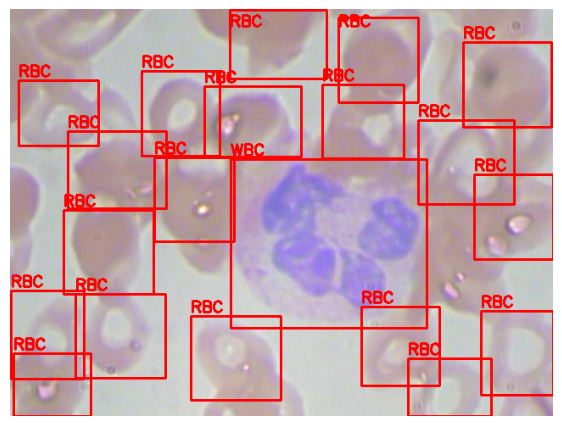

Sample image: BloodImage_00002.jpg


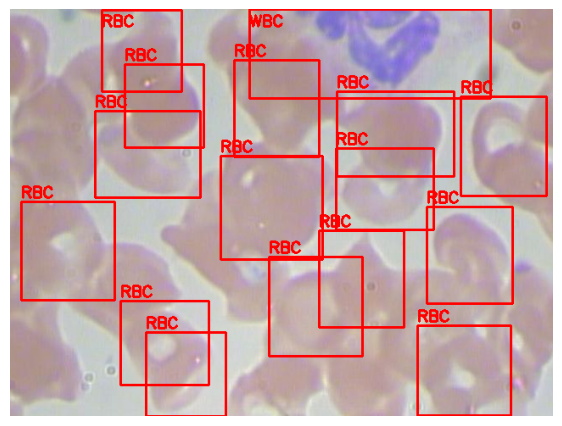

Sample image: BloodImage_00003.jpg


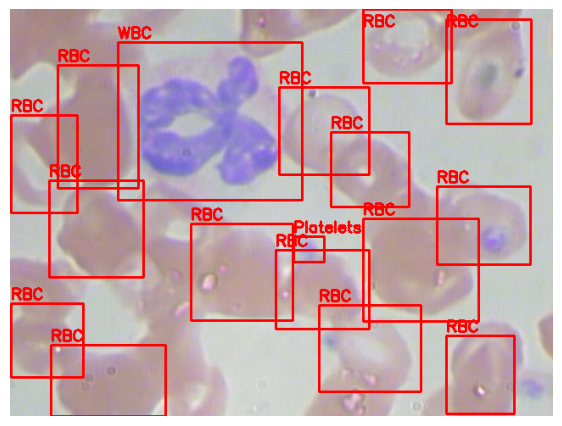

Sample image: BloodImage_00004.jpg


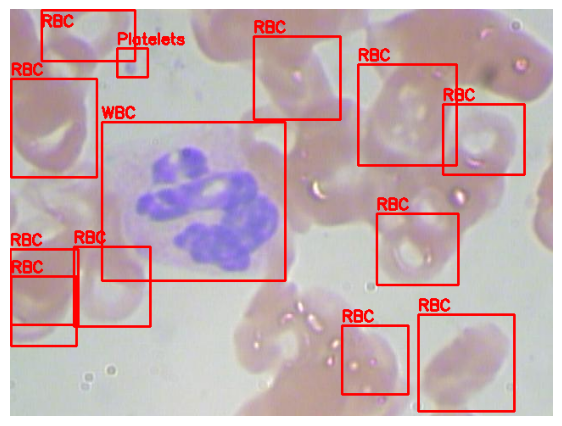

Sample image: BloodImage_00009.jpg


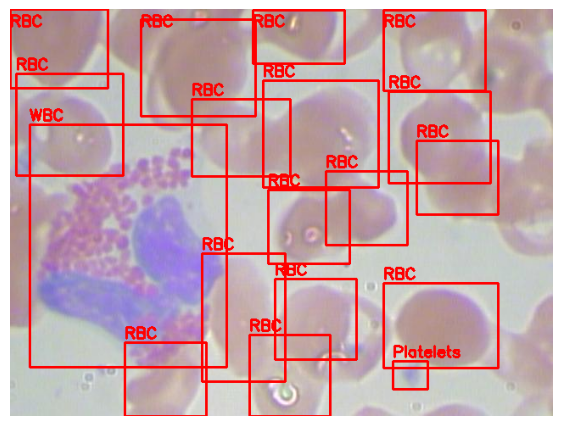

Sample image: BloodImage_00011.jpg


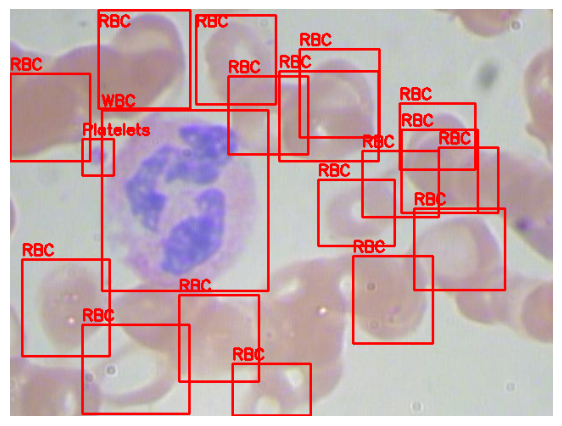

In [10]:
def load_yolo_labels(label_path):
    labels = []
    if not Path(label_path).exists():
        return labels

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            labels.append([class_id, x_center, y_center, width, height])
    return labels

def draw_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]

    labels = load_yolo_labels(label_path)

    for class_id, x_center, y_center, width, height in labels:
        xmin, ymin, xmax, ymax = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        cv2.putText(
            image,
            CLASS_NAMES[class_id],
            (xmin, max(20, ymin - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# After completing yolo_to_xyxy, run this cell
train_images = sorted((YOLO_DIR / 'images' / 'train').glob('*.jpg'))

for img_path in train_images[:6]:
    label_path = YOLO_DIR / 'labels' / 'train' / f'{img_path.stem}.txt'
    print("Sample image:", img_path.name)
    draw_yolo_labels(img_path, label_path)

## Questions

**1. Are the boxes well aligned with the objects?**  
Yes, the boxes are placed correctly around the cells after we implement.

**2. Which objects are small?**  
Platelets are very small. They are rare in the images and appear as tiny dots, much smaller than RBCs or WBCs.

**3. Which objects are close to each other?**  
RBCs are very close. They are packed together and often touch or overlap each other.

**4. Which class will be hardest to detect? Why?**  
Platelets will be the hardest to detect. They are very small, so the model gets very little information from them. As the image passes through the network layers, the feature maps get smaller and smaller. The signal from a tiny object like a Platelet can disappear completely before reaching the detection head. They also have the fewest training examples, so the model does not learn much about them.

# 7.  IoU

IoU means **Intersection over Union**.

It measures how much a predicted box overlaps with a ground-truth box.

```text
IoU = area(intersection) / area(union)
```


# 8. Implement IoU

Complete the function below.

Input boxes use the pixel format:

```text
[xmin, ymin, xmax, ymax]
```

In [11]:
def compute_iou(box_a, box_b):
    """
    Compute IoU between two boxes.

    box_a and box_b are in [xmin, ymin, xmax, ymax] format.

    TODO :
    Complete the implementation.
    """
    x_left   = max(box_a[0], box_b[0])
    y_top    = max(box_a[1], box_b[1])
    x_right  = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_w = max(0, x_right - x_left)
    inter_h = max(0, y_bottom - y_top)
    inter_area = inter_w * inter_h

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    union = area_a + area_b - inter_area

    if union == 0:
        return 0.0
    return inter_area / union

In [12]:
# Test your IoU function

box_a = [50, 50, 150, 150]
box_b = [100, 100, 200, 200]

iou = compute_iou(box_a, box_b)
print("IoU:", iou)

# Expected value: approximately 0.1429
assert abs(iou - 0.1429) < 1e-3, "IoU is not correct. Check your implementation."

IoU: 0.14285714285714285


# 9. Load a small YOLO model

The model starts from pretrained weights.  

In [13]:
# YOLOv8 nano is small
# If your environment uses a newer Ultralytics model naming convention,
# you may replace "yolov8n.pt" with another nano model available in your setup.

model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

# 10. Inference before fine-tuning

Before training on BCCD, test the pretrained model.

## Questions

**1. Does the pretrained model detect RBC, WBC, or Platelets?**  
No, it does not detect blood cells. It may output some boxes, but the labels are wrong (e.g. 'sports ball').

**2. Why or why not?**  
The model was trained on everyday photos, not microscope images. It has never seen blood cells, so it cannot recognize them.

**3. What classes was the model trained on?**  
It was trained on the 80 COCO classes, such as person, car, dog, chair, and bottle.

Testing pretrained model on: /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00058.jpg

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00058.jpg: 480x640 1 donut, 275.4ms
Speed: 9.1ms preprocess, 275.4ms inference, 106.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


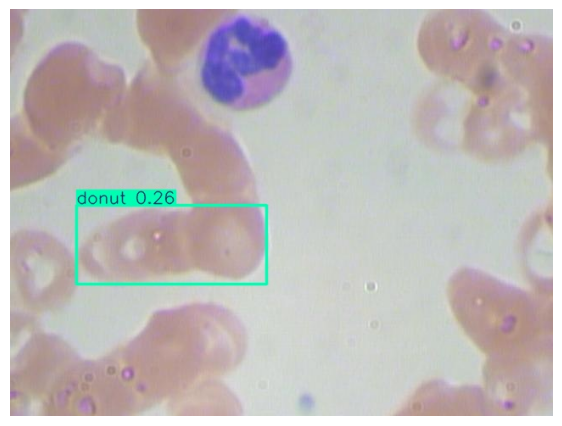

In [14]:
test_image = random.choice(list((YOLO_DIR / "images" / "test").glob("*.jpg")))
print("Testing pretrained model on:", test_image)

pre_results = model.predict(
    source=str(test_image),
    conf=0.25,
    device=DEVICE,
    save=True
)

# Display the saved prediction
pred_img = Path(pre_results[0].save_dir) / test_image.name
if pred_img.exists():
    img = cv2.imread(str(pred_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Prediction image was not found. Check Ultralytics output directory:", pre_results[0].save_dir)

# 11. Train YOLO on the custom dataset

This cell uses the configuration selected earlier.

You can reduce `EPOCHS` if the runtime is too long.

In [15]:
data_yaml_path = YOLO_DIR / "data.yaml"

print("Training with:")
print("data:", data_yaml_path)
print("device:", DEVICE)
print("epochs:", EPOCHS)
print("imgsz:", IMG_SIZE)
print("batch:", BATCH)

train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0,
    name="bccd_yolo_tp",
    exist_ok=True
)

Training with:
data: /content/object_detection_tp/bccd_yolo/data.yaml
device: 0
epochs: 15
imgsz: 416
batch: 8
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/object_detection_tp/bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

# 12. Validate the trained model

Validation gives detection metrics such as precision, recall, and mAP.

Do not worry if the score is not very high.  
This is a small dataset and short training.

In [19]:
metrics = model.val(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0
)

print(f'\n--- Validation results ---')
print(f'meanAveargePrecision_50       : {metrics.box.map50:.3f}')
print(f'mAP_50-95    : {metrics.box.map:.3f}')
print(f'Precision    : {metrics.box.mp:.3f}')
print(f'Recall       : {metrics.box.mr:.3f}')
print(f'\nPer class mAP_50:')
for name, ap in zip(CLASS_NAMES, metrics.box.ap50):
    print(f'  {name:<12}: {ap:.3f}')


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1170.2±321.9 MB/s, size: 20.4 KB)
val: Scanning /content/object_detection_tp/bccd_yolo/labels/val.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 8.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.6it/s 1.1s
                   all         32        474      0.752      0.816      0.791        0.5
                   RBC         31        411      0.653      0.843      0.789      0.492
                   WBC         29         30      0.883          1      0.971       0.75
             Platelets         19         33      0.721      0.606      0.615       0.26
Speed: 0.9ms preprocess, 6.2ms inference, 0.0ms loss, 9.8ms postprocess per image
Results saved to /content/runs/detect/val-4

--- Validation results ---
meanAveargePrecision_50       : 0.791
mAP_50-95   

# 13. Run inference after fine-tuning

Now test the fine-tuned model on images it did not train on.

In [51]:
model = YOLO('runs/detect/bccd_yolo_tp/weights/best.pt')


Number of test images: 16
Results saved to /content/runs/detect/predict-4
Saved predictions to: /content/runs/detect/predict-4


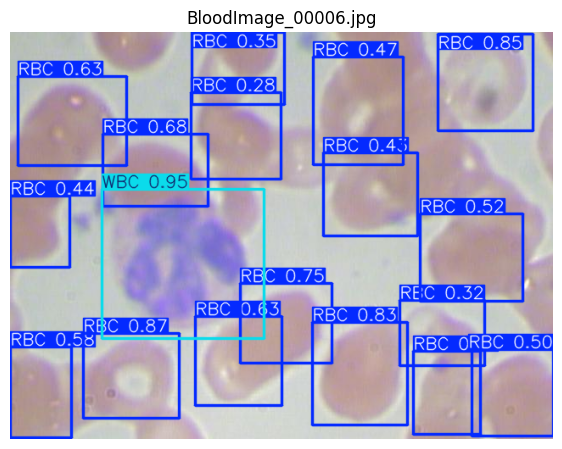

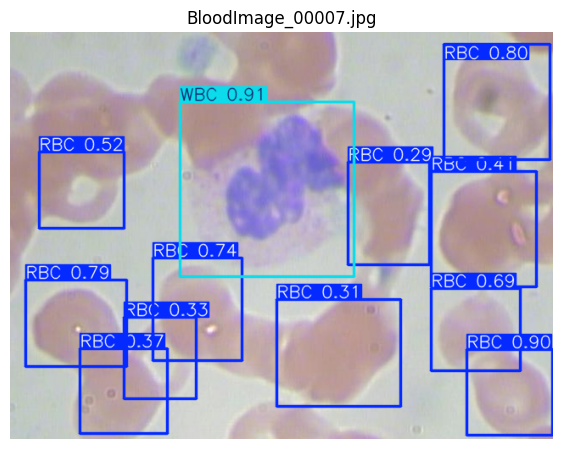

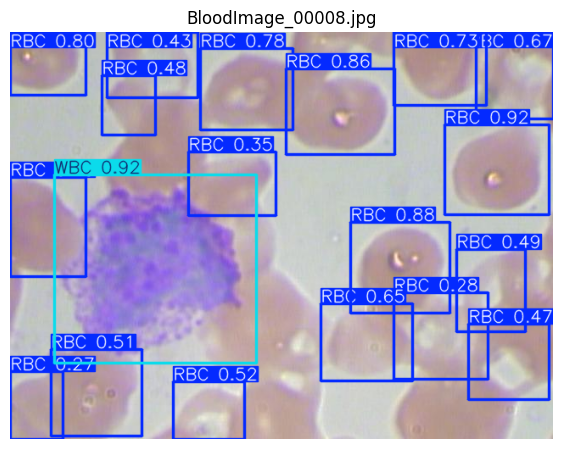

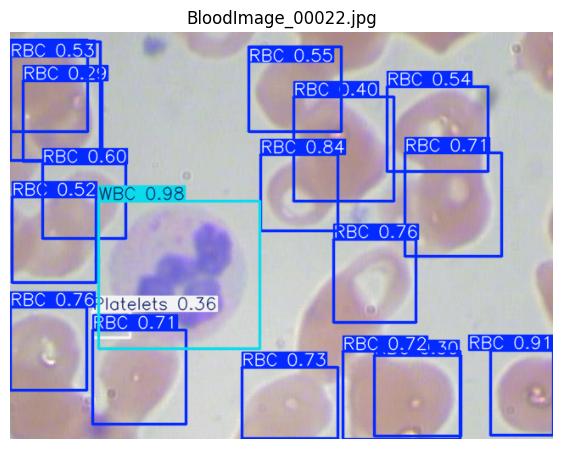

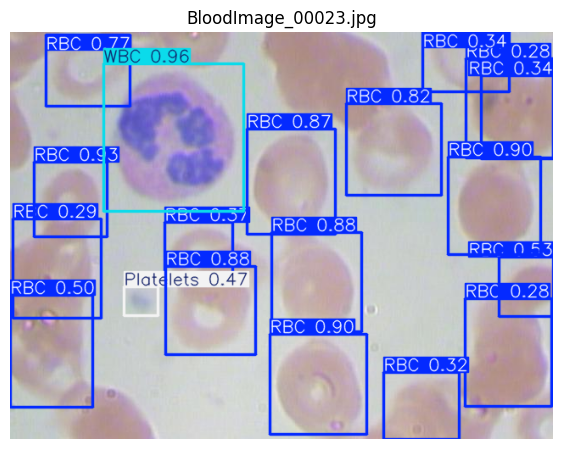

In [61]:
test_images = sorted((YOLO_DIR / 'images' / 'test').glob('*.jpg'))
print('Number of test images:', len(test_images))

results = model.predict(
    source=[str(p) for p in test_images[:5]],
    conf=0.25,
    imgsz=IMG_SIZE,
    device=DEVICE,
    save=True
)

print('Saved predictions to:', results[0].save_dir)

for r, img_path in zip(results, test_images[:5]):
    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis('off')
    plt.show()


In [62]:
# Display saved predictions
save_dir = Path(results[0].save_dir)

for img_path in test_images[:5]:
    pred_path = save_dir / img_path.name
    print(pred_path)
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

/content/runs/detect/predict-4/BloodImage_00006.jpg
/content/runs/detect/predict-4/BloodImage_00007.jpg
/content/runs/detect/predict-4/BloodImage_00008.jpg
/content/runs/detect/predict-4/BloodImage_00022.jpg
/content/runs/detect/predict-4/BloodImage_00023.jpg


# 14. Confidence threshold experiment

YOLO outputs detections with confidence scores.

If the threshold is low, the model keeps more boxes.  
If the threshold is high, the model keeps fewer boxes.

## Exercise

Try several confidence thresholds.

Experiment image: BloodImage_00064.jpg

Running prediction with conf=0.05
Results saved to /content/runs/detect/predict-4


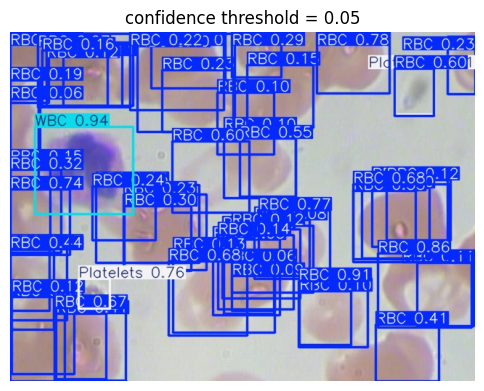


Running prediction with conf=0.25
Results saved to /content/runs/detect/predict-4


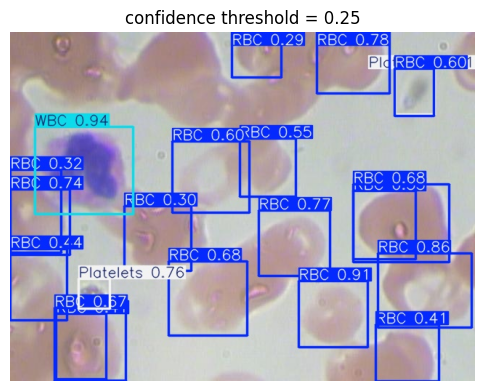


Running prediction with conf=0.5
Results saved to /content/runs/detect/predict-4


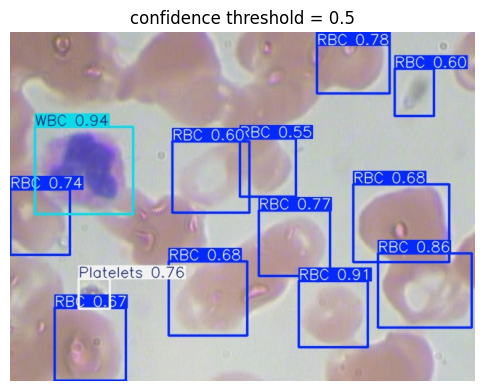


Running prediction with conf=0.75
Results saved to /content/runs/detect/predict-4


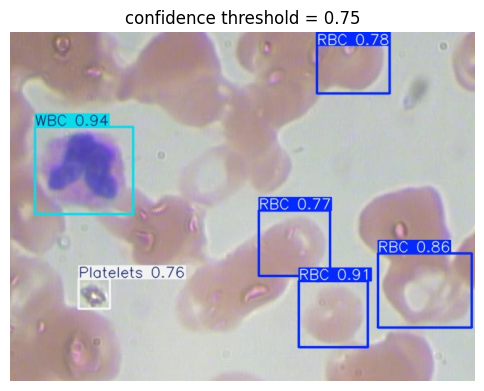


Running prediction with conf=0.9
Results saved to /content/runs/detect/predict-4


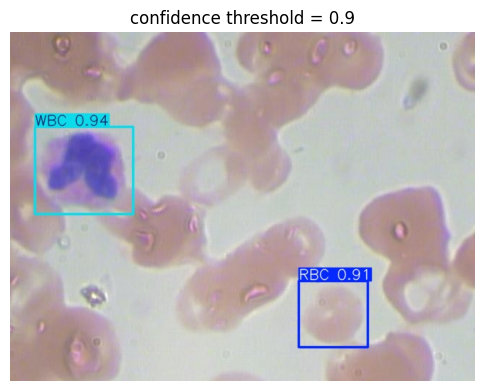

In [63]:
# TODO
# Add at least four confidence thresholds.
confidence_thresholds = [0.05, 0.25, 0.5, 0.75, 0.9]  # TODO

experiment_image = random.choice(test_images)
print("Experiment image:", experiment_image.name)

for conf in confidence_thresholds:
    print(f"\nRunning prediction with conf={conf}")
    pred = model.predict(
        source=str(experiment_image),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        save=True
    )

    pred_path = Path(pred[0].save_dir) / experiment_image.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"confidence threshold = {conf}")
        plt.axis("off")
        plt.show()

## Answers

**1. What happens when the confidence threshold is very low?**  
The model keeps too many boxes. At conf=0.05, the image is covered with overlapping boxes, including many wrong detections. It is hard to read anything.

**2. What happens when the confidence threshold is very high?**  
The model keeps very few boxes. At conf=0.9, only 2 objects are detected (WBC and one RBC). Most cells are completely missed.

**3. Which threshold gives the best visual result on your image?**  
conf=0.25 gives the best result. The boxes are clean, most cells are detected, and we can even see a Platelet detected at 0.76.

**4. How does the threshold affect false positives?**  
A lower threshold increases false positives. At conf=0.05, many boxes appear on background regions where there is no real object.

**5. How does the threshold affect false negatives?**  
A higher threshold increases false negatives. At conf=0.9, most RBCs are missed because their confidence score is below the threshold.

# 15. Compare predictions with ground truth using IoU

We will now compare model predictions to ground-truth boxes.

A prediction is usually considered correct if:

```text
class is correct AND IoU >= 0.5
```

This is a simplified evaluation, not full mAP.

In [64]:
def get_ground_truth_boxes(image_path):
    label_path = YOLO_DIR / "labels" / "test" / f"{image_path.stem}.txt"
    labels = load_yolo_labels(label_path)

    image = cv2.imread(str(image_path))
    img_h, img_w = image.shape[:2]

    gt = []
    for class_id, x_center, y_center, width, height in labels:
        box = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        gt.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "box": list(map(float, box))
        })
    return gt

def get_prediction_boxes(image_path, conf=0.25):
    pred = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        verbose=False
    )[0]

    detections = []
    if pred.boxes is None:
        return detections

    for box, cls, score in zip(pred.boxes.xyxy.cpu().numpy(),
                               pred.boxes.cls.cpu().numpy(),
                               pred.boxes.conf.cpu().numpy()):
        class_id = int(cls)
        detections.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else str(class_id),
            "confidence": float(score),
            "box": box.tolist()
        })
    return detections

In [65]:
eval_image = random.choice(test_images)
gt_boxes   = get_ground_truth_boxes(eval_image)
pred_boxes = get_prediction_boxes(eval_image, conf=0.25)

print('Image:', eval_image.name)
print('Ground truth boxes:', len(gt_boxes))
print('Predicted boxes:', len(pred_boxes))

for i, pred in enumerate(pred_boxes):
    best_iou = 0.0

    for gt in gt_boxes:
        if gt['class_id'] == pred['class_id']:
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou

    status = 'correct' if best_iou >= 0.5 else 'incorrect'

    print(
        f"Prediction {i}: class={pred['class_name']}, "
        f"conf={pred['confidence']:.2f}, best IoU={best_iou:.3f}, status={status}"
    )


Image: BloodImage_00008.jpg
Ground truth boxes: 20
Predicted boxes: 19
Prediction 0: class=RBC, conf=0.92, best IoU=0.791, status=correct
Prediction 1: class=WBC, conf=0.92, best IoU=0.809, status=correct
Prediction 2: class=RBC, conf=0.88, best IoU=0.931, status=correct
Prediction 3: class=RBC, conf=0.86, best IoU=0.723, status=correct
Prediction 4: class=RBC, conf=0.80, best IoU=0.831, status=correct
Prediction 5: class=RBC, conf=0.78, best IoU=0.900, status=correct
Prediction 6: class=RBC, conf=0.73, best IoU=0.839, status=correct
Prediction 7: class=RBC, conf=0.73, best IoU=0.807, status=correct
Prediction 8: class=RBC, conf=0.67, best IoU=0.063, status=incorrect
Prediction 9: class=RBC, conf=0.65, best IoU=0.908, status=correct
Prediction 10: class=RBC, conf=0.52, best IoU=0.710, status=correct
Prediction 11: class=RBC, conf=0.51, best IoU=0.000, status=incorrect
Prediction 12: class=RBC, conf=0.49, best IoU=0.684, status=correct
Prediction 13: class=RBC, conf=0.48, best IoU=0.179

In [67]:
eval_image = random.choice(test_images)
gt_boxes   = get_ground_truth_boxes(eval_image)
pred_boxes = get_prediction_boxes(eval_image, conf=0.25)

print('Image:', eval_image.name)
print('Ground truth boxes:', len(gt_boxes))
print('Predicted boxes:', len(pred_boxes))

for i, pred in enumerate(pred_boxes):
    best_iou = 0.0

    for gt in gt_boxes:
        if gt['class_id'] == pred['class_id']:
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou

    status = 'correct' if best_iou >= 0.5 else 'incorrect'

    print(
        f"Prediction {i}: class={pred['class_name']}, "
        f"conf={pred['confidence']:.2f}, best IoU={best_iou:.3f}, status={status}"
    )


Image: BloodImage_00064.jpg
Ground truth boxes: 11
Predicted boxes: 21
Prediction 0: class=WBC, conf=0.94, best IoU=0.876, status=correct
Prediction 1: class=RBC, conf=0.91, best IoU=0.895, status=correct
Prediction 2: class=RBC, conf=0.86, best IoU=0.722, status=correct
Prediction 3: class=RBC, conf=0.78, best IoU=0.841, status=correct
Prediction 4: class=RBC, conf=0.77, best IoU=0.818, status=correct
Prediction 5: class=Platelets, conf=0.76, best IoU=0.000, status=incorrect
Prediction 6: class=RBC, conf=0.74, best IoU=0.828, status=correct
Prediction 7: class=RBC, conf=0.68, best IoU=0.832, status=correct
Prediction 8: class=RBC, conf=0.68, best IoU=0.829, status=correct
Prediction 9: class=RBC, conf=0.67, best IoU=0.000, status=incorrect
Prediction 10: class=RBC, conf=0.60, best IoU=0.803, status=correct
Prediction 11: class=RBC, conf=0.60, best IoU=0.000, status=incorrect
Prediction 12: class=RBC, conf=0.55, best IoU=0.095, status=incorrect
Prediction 13: class=RBC, conf=0.44, best

## Questions

**1. Can a high-confidence prediction still be wrong?**  
Yes. In BloodImage_00008, Prediction 8 has conf=0.67 but IoU=0.063, it is marked incorrect. In BloodImage_00064, the Platelets prediction has conf=0.76 but IoU=0.000. The model is confident, but the box does not match any ground truth object.

**2. Can a box be well placed but have the wrong class?**  
Yes. In BloodImage_00064, Prediction 1 detects an RBC with conf=0.91 and IoU=0.895, the box is very well placed. However, the model could have labeled it as another class if the classes looked similar. This is common between RBC and Platelets since they can look alike at low confidence.

# 16. Non-Maximum Suppression intuition

Object detectors often predict multiple boxes around the same object.

**Non-Maximum Suppression**, or NMS, removes duplicate boxes.

Basic idea:

1. Keep the box with the highest confidence.
2. Remove other boxes that overlap too much with it.
3. Repeat.

The overlap is measured using IoU.

# 17. Implement a simple NMS



now you will implement a simplified version of NMS.

Object detectors may predict several boxes around the same object.  
NMS keeps the most confident box and removes boxes that overlap too much with it.

The algorithm is:

1. Sort boxes by confidence score.
2. Select the box with the highest score.
3. Remove all boxes with IoU greater than a threshold.
4. Repeat until no boxes remain.

In [68]:
def simple_nms(detections, iou_threshold=0.5):
    """
    Simple Non-Maximum Suppression.

    detections: list of dicts with keys 'box', 'score', 'class_id'.
    Returns the subset of detections to keep after NMS.
    """
    detections = sorted(detections, key=lambda x: x['score'], reverse=True)

    kept = []

    while len(detections) > 0:
        best = detections.pop(0)
        kept.append(best)

        remaining = []
        for det in detections:
            if det['class_id'] != best['class_id']:
                remaining.append(det)
            else:
                iou = compute_iou(best['box'], det['box'])
                if iou < iou_threshold:
                    remaining.append(det)
        detections = remaining

    return kept


In [69]:
# Test it
example_detections = [
    {"box": [50, 50, 150, 150], "score": 0.95, "class_id": 0},
    {"box": [60, 60, 155, 155], "score": 0.80, "class_id": 0},
    {"box": [200, 200, 300, 300], "score": 0.90, "class_id": 0},
    {"box": [55, 55, 148, 148], "score": 0.70, "class_id": 0},
    {"box": [52, 52, 151, 151], "score": 0.88, "class_id": 1},
]

kept_boxes = simple_nms(example_detections, iou_threshold=0.5)

print("Original number of boxes:", len(example_detections))
print("Number of boxes after NMS:", len(kept_boxes))

for box in kept_boxes:
    print(box)

Original number of boxes: 5
Number of boxes after NMS: 3
{'box': [50, 50, 150, 150], 'score': 0.95, 'class_id': 0}
{'box': [200, 200, 300, 300], 'score': 0.9, 'class_id': 0}
{'box': [52, 52, 151, 151], 'score': 0.88, 'class_id': 1}


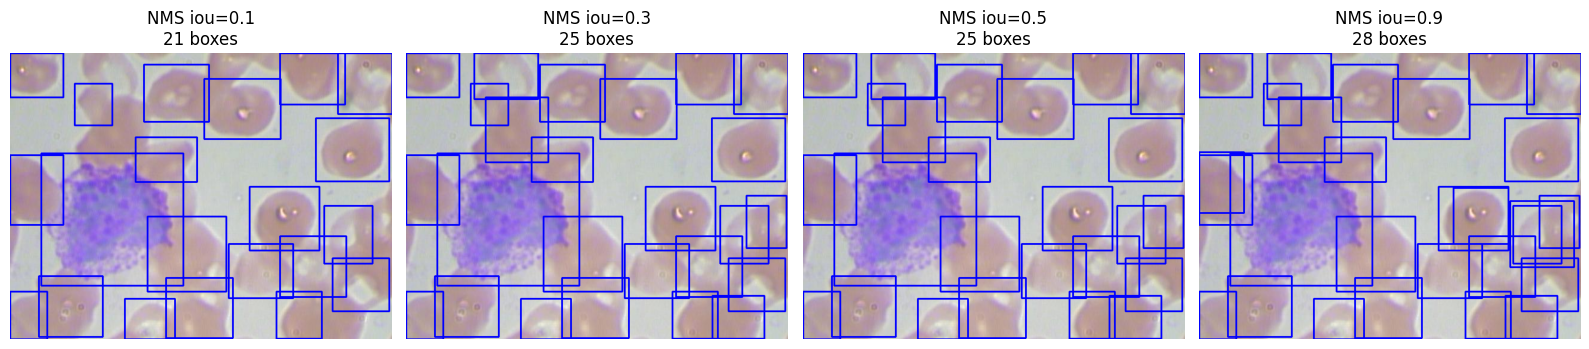

In [71]:
demo_image = random.choice(test_images)
raw = model.predict(source=str(demo_image), conf=0.1,
                    imgsz=IMG_SIZE, device=DEVICE, verbose=False)[0]

detections = [
    {'box': b.tolist(), 'score': float(s), 'class_id': int(c)}
    for b, s, c in zip(raw.boxes.xyxy.cpu().numpy(),
                       raw.boxes.conf.cpu().numpy(),
                       raw.boxes.cls.cpu().numpy())
]

image = cv2.cvtColor(cv2.imread(str(demo_image)), cv2.COLOR_BGR2RGB)

thresholds = [0.1, 0.3, 0.5, 0.9]
fig, axes = plt.subplots(1, len(thresholds), figsize=(16, 5))

for ax, iou_t in zip(axes, thresholds):
    kept = simple_nms(detections, iou_threshold=iou_t)
    img = image.copy()
    for d in kept:
        x1, y1, x2, y2 = map(int, d['box'])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    ax.imshow(img)
    ax.set_title(f'NMS iou={iou_t}\n{len(kept)} boxes')
    ax.axis('off')

plt.tight_layout()
plt.show()
